# 🎨 Segmentação de Imagens Coloridas por Agrupamento K-Means
### Universidade Federal do Piauí – UFPI | Campus Senador Helvídio Nunes de Barros
**Disciplina:** Tópicos Especiais em Visão Computacional — Prof. José Denes Lima Araújo  
**Grupo 4:** Técnicas de Segmentação Baseada em Região (Seção 10.5 — Gonzalez & Woods, 4ª Edição)  
**Apresentador:** Integrante 3 — *O Analista Experimental (Prática, Particularidades & Fechamento)*  

---

## 📌 Contexto e Objetivos (Slide 10 do Seminário)
Este notebook implementa a segmentação de imagens baseada em **Clustering K-Means** no espaço de cores **CIE $L^*a^*b^*$**, conforme abordado na seção *"Region Segmentation Using Clustering and Superpixels"* da 4ª Edição do livro clássico de Rafael C. Gonzalez e Richard E. Woods.

### Formulação Matemática do K-Means
Diferente do Watershed (que opera sobre o relevo morfológico e conectividade espacial), o K-Means aborda a segmentação sob o paradigma do **aprendizado de máquina não supervisionado**.
Dado um conjunto de $N$ pixels representados por vetores de características $z_i$, o algoritmo particiona a imagem em $K$ grupos (clusters) disjuntos $C_1, C_2, \dots, C_K$ com centróides $m_1, m_2, \dots, m_K$, minimizando a soma das distâncias euclidianas quadradas (compactude / inércia $J$):
$$J = \sum_{k=1}^{K} \sum_{z_i \in C_k} \|z_i - m_k\|^2$$

### Por que usar o espaço de cor CIE $L^*a^*b^*$?
No espaço RGB comum, variações de iluminação e sombras alteram os três canais $(R, G, B)$ simultaneamente, confundindo o cálculo de distâncias euclidianas. O espaço $L^*a^*b^*$ desacopla:
- $L^*$: Luminância (percepção de claro/escuro)
- $a^*$: Eixo cromático verde-vermelho
- $b^*$: Eixo cromático azul-amarelo

Isso permite agrupar pixels com base em sua cor intrínseca real, atenuando o impacto de sombras.


In [1]:
# 1. Importação das Bibliotecas e Configurações de Ambiente (Compatível com Google Colab)
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.linewidth'] = 0.8

os.makedirs("imagens", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

# Verificação e download da imagem de teste canônica (borboleta em vegetação)
img_path = os.path.join("imagens", "cena_colorida.jpg")
if not os.path.exists(img_path):
    url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg"
    print(f"Baixando imagem de teste de: {url}")
    urllib.request.urlretrieve(url, img_path)
    print("Download concluído com sucesso!")
else:
    print(f"Imagem encontrada localmente: {img_path}")


Imagem encontrada localmente: imagens\cena_colorida.jpg


## 2. Leitura da Imagem e Decomposição de Canais em $L^*a^*b^*$
Carregamos a cena colorida contendo três planos visuais nítidos:
1. **Plano de Fundo:** Área superior suave / desfoque óptico
2. **Vegetação:** Folhagem verde estriada
3. **Objeto de Interesse:** Borboleta com marcações pretas, manchas brancas e detalhes coloridos


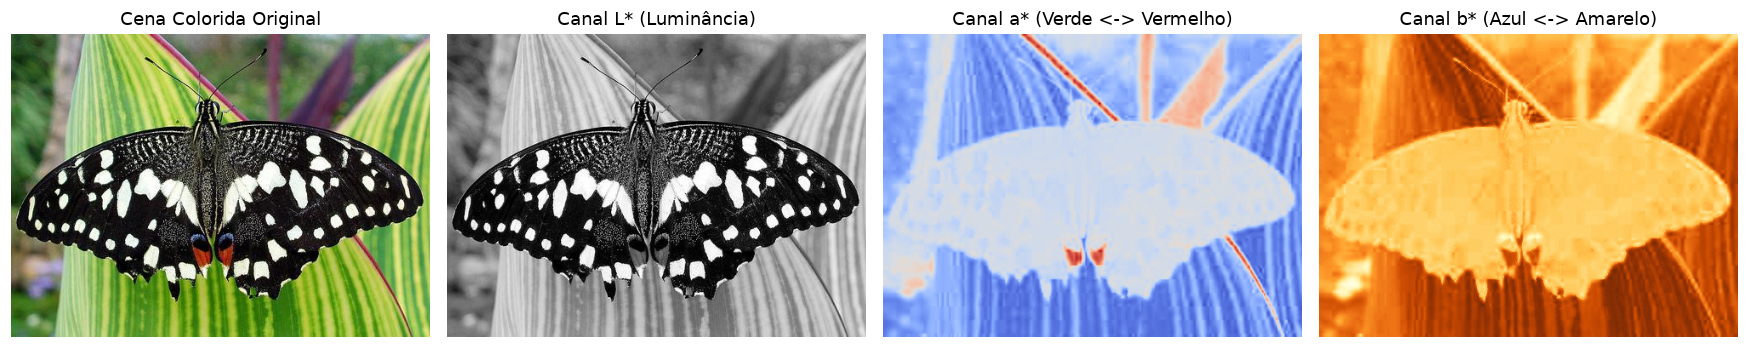

In [2]:
# Leitura BGR, conversão para RGB e para o espaço CIE L*a*b*
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

L, a, b = cv2.split(img_lab)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_rgb)
ax[0].set_title("Cena Colorida Original")
ax[0].axis("off")

im_L = ax[1].imshow(L, cmap="gray")
ax[1].set_title("Canal L* (Luminância)")
ax[1].axis("off")

im_a = ax[2].imshow(a, cmap="coolwarm")
ax[2].set_title("Canal a* (Verde <-> Vermelho)")
ax[2].axis("off")

im_b = ax[3].imshow(b, cmap="YlOrBr")
ax[3].set_title("Canal b* (Azul <-> Amarelo)")
ax[3].axis("off")

plt.tight_layout()
plt.show()


## 3. Função Modular de Execução do K-Means
Implementamos uma função modular que reestrutura a matriz de pixels $(H \times W, 3)$ em um vetor de amostras $(N, 3)$ em ponto flutuante, executa o algoritmo `cv2.kmeans` com critério rigoroso de convergência e reconstrói tanto a imagem quantizada em cores quanto o mapa de rótulos de cada pixel.


In [3]:
def executar_kmeans(imagem_rgb, k, usar_lab=True, tentativas=10, max_iter=100, eps=0.2):
    """
    Executa o algoritmo K-Means nos pixels de uma imagem.
    
    Parâmetros:
      - imagem_rgb: Imagem de entrada no formato RGB.
      - k: Número de agrupamentos desejados.
      - usar_lab: Se True, projeta as cores no espaço CIE L*a*b* antes do agrupamento.
      - tentativas: Número de reinicializações aleatórias (retém a de menor inércia).
      - max_iter: Número máximo de iterações por execução.
      - eps: Variação mínima do deslocamento dos centroides para declarar convergência.
    
    Retorna:
      - imagem_quantizada_rgb: Imagem com cores substituídas pelos centroides.
      - mapa_rotulos: Matriz 2D (H, W) com o identificador de cluster (0 a K-1).
      - compactude: Soma dos erros quadráticos intra-cluster (J).
      - centroides: Matriz com as coordenadas dos centroides no espaço utilizado.
    """
    if usar_lab:
        img_espaco = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2LAB)
    else:
        img_espaco = imagem_rgb.copy()
        
    H, W, C = img_espaco.shape
    # Reformatação da matriz (H, W, 3) para (N, 3) do tipo float32
    amostras = img_espaco.reshape((-1, 3)).astype(np.float32)
    
    # Critério de parada: ATINGIR max_iter OU VARIAÇÃO INFERIOR A eps
    criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, max_iter, eps)
    
    # Execução do K-Means
    compactude, rotulos, centroides = cv2.kmeans(
        amostras, k, None, criterio, tentativas, cv2.KMEANS_RANDOM_CENTERS
    )
    
    # Converte os centroides para inteiros de 8 bits
    centroides = np.uint8(centroides)
    
    # Reconstrói a imagem quantizada substituindo cada pixel pelo seu respectivo centroide
    imagem_quantizada = centroides[rotulos.flatten()].reshape((H, W, C))
    mapa_rotulos = rotulos.reshape((H, W))
    
    if usar_lab:
        imagem_quantizada_rgb = cv2.cvtColor(imagem_quantizada, cv2.COLOR_LAB2RGB)
    else:
        imagem_quantizada_rgb = imagem_quantizada
        
    return imagem_quantizada_rgb, mapa_rotulos, compactude, centroides

print("Função executar_kmeans compilada com sucesso!")


Função executar_kmeans compilada com sucesso!


## 4. Variação Sistemática de $K \in \{2, 3, 5\}$
Conforme estipulado no roteiro do seminário, avaliamos o comportamento do K-Means variando o hiperparâmetro $K$:
- **$K = 2$:** Sub-segmentação extrema. A imagem é forçada a apenas dois grupos (ex: tons escuros da borboleta vs todo o restante da cena).
- **$K = 3$:** Ponto de equilíbrio ótimo! Isola com precisão os 3 componentes da cena: o plano de fundo, a folhagem verde e o corpo da borboleta.
- **$K = 5$:** Sobre-segmentação cromática. A folha e o fundo começam a ser divididos em múltiplos clusters devido a gradientes de luminosidade.


=== COMPARAÇÃO DE INÉRCIA (COMPACTUDE J) EM FUNÇÃO DE K ===


K = 2: Inércia J = 3.43e+08 (Redução na dispersão intra-cluster)


K = 3: Inércia J = 1.83e+08 (Redução na dispersão intra-cluster)


K = 5: Inércia J = 1.03e+08 (Redução na dispersão intra-cluster)


Gráfico comparativo de K salvo em: resultados\kmeans_comparativo_k.png


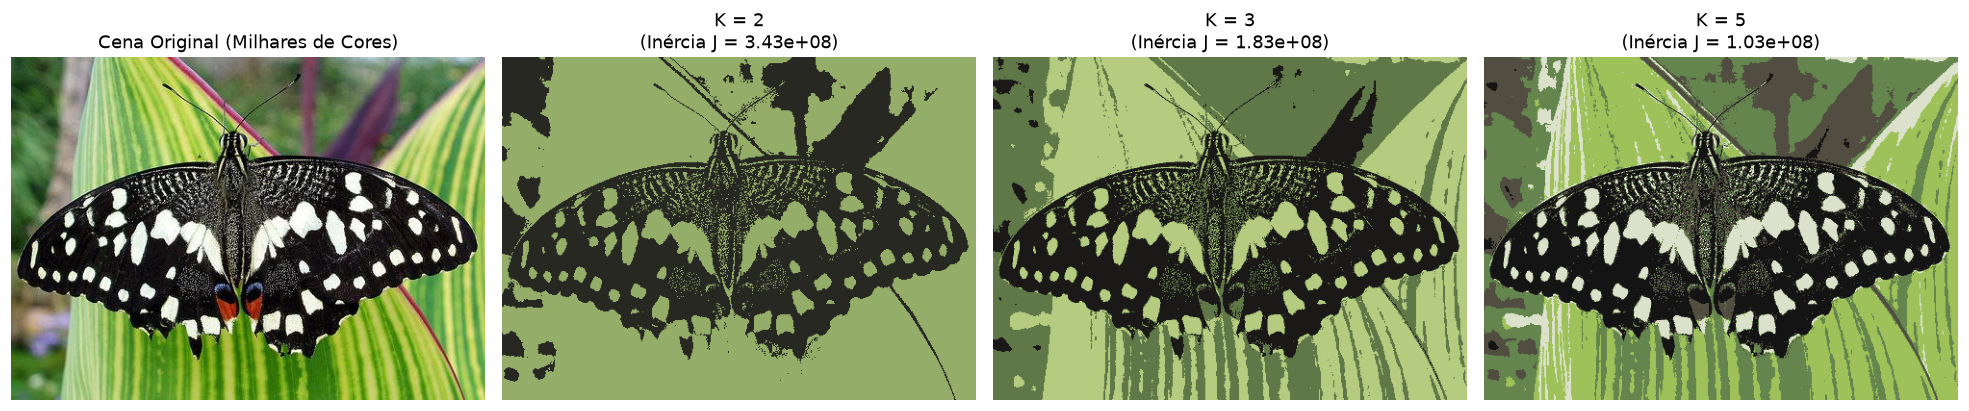

In [4]:
k_valores = [2, 3, 5]
resultados_k = {}

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(img_rgb)
ax[0].set_title("Cena Original (Milhares de Cores)")
ax[0].axis("off")

print("=== COMPARAÇÃO DE INÉRCIA (COMPACTUDE J) EM FUNÇÃO DE K ===")
for idx, k in enumerate(k_valores, 1):
    seg_rgb, labels_2d, J, cents = executar_kmeans(img_rgb, k, usar_lab=True)
    resultados_k[k] = (seg_rgb, labels_2d, J, cents)
    
    print(f"K = {k}: Inércia J = {J:.2e} (Redução na dispersão intra-cluster)")
    
    ax[idx].imshow(seg_rgb)
    ax[idx].set_title(f"K = {k}\n(Inércia J = {J:.2e})")
    ax[idx].axis("off")

plt.tight_layout()
output_k = os.path.join("resultados", "kmeans_comparativo_k.png")
plt.savefig(output_k, dpi=180, bbox_inches='tight')
print(f"Gráfico comparativo de K salvo em: {output_k}")
plt.show()


## 5. Análise Detalhada de $K = 3$: Isolamento dos Planos Visuais
Vamos analisar individualmente cada um dos 3 clusters gerados quando $K = 3$.
Geramos a máscara binária de cada cluster e o recorte colorido correspondente na imagem original:


=== DISTRIBUIÇÃO ESTATÍSTICA DOS CLUSTERS (K = 3) ===
Cluster 1: 59071 pixels (33.7% da imagem)
Cluster 2: 66243 pixels (37.7% da imagem)
Cluster 3: 50194 pixels (28.6% da imagem)


Máscaras de clusters salvas em: resultados\kmeans_mascaras_k3.png


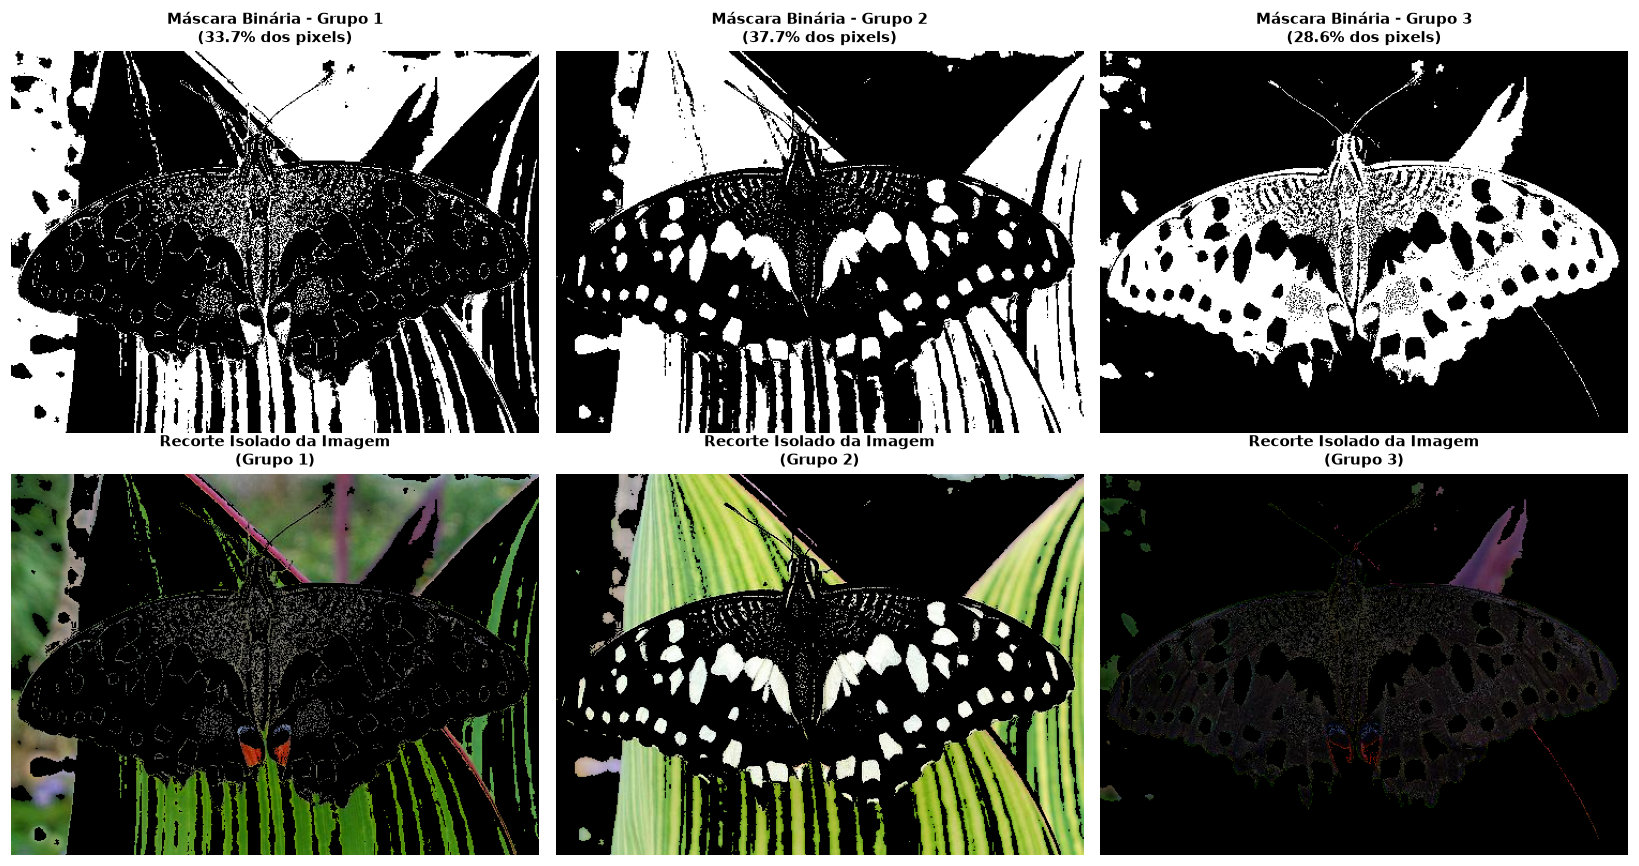

In [5]:
seg_k3, labels_k3, _, cents_k3 = resultados_k[3]
total_pixels = labels_k3.size

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

nomes_sugeridos = [
    "Cluster 1: Objeto de Interesse (Borboleta / Tons Escuros)",
    "Cluster 2: Vegetação (Folhagem Verde)",
    "Cluster 3: Plano de Fundo e Reflexos Claros"
]

print("=== DISTRIBUIÇÃO ESTATÍSTICA DOS CLUSTERS (K = 3) ===")
for c in range(3):
    mask = (labels_k3 == c)
    pct = (np.sum(mask) / total_pixels) * 100
    print(f"Cluster {c+1}: {np.sum(mask)} pixels ({pct:.1f}% da imagem)")
    
    # Recorte da imagem original preservando apenas os pixels deste cluster
    recorte = np.zeros_like(img_rgb)
    recorte[mask] = img_rgb[mask]
    
    # Linha 1: Máscara Binária
    axes[0, c].imshow(mask, cmap="gray")
    axes[0, c].set_title(f"Máscara Binária - Grupo {c+1}\n({pct:.1f}% dos pixels)", fontsize=10, fontweight='bold')
    axes[0, c].axis("off")
    
    # Linha 2: Conteúdo Cromático Real Isolado
    axes[1, c].imshow(recorte)
    axes[1, c].set_title(f"Recorte Isolado da Imagem\n(Grupo {c+1})", fontsize=10, fontweight='bold')
    axes[1, c].axis("off")

plt.tight_layout()
output_mascaras = os.path.join("resultados", "kmeans_mascaras_k3.png")
plt.savefig(output_mascaras, dpi=180, bbox_inches='tight')
print(f"Máscaras de clusters salvas em: {output_mascaras}")
plt.show()


## 6. A Grande Particularidade: Ausência de Restrição Espacial
Observe com extrema atenção as máscaras acima:
- O K-Means tradicional opera **estritamente no espaço espectral de cores** $(L^*, a^*, b^*)$, ignorando totalmente as coordenadas espaciais $(x, y)$ dos pixels!
- **O que acontece na prática?** As manchas brancas nas pontas das asas da borboleta e os pequenos reflexos de luz na folha de fundo possuem a mesma assinatura tonal clara. Por isso, eles recebem **o mesmo rótulo de cluster**, mesmo estando localizados em extremidades espaciais totalmente opostas da imagem!
- **Conexão com a 4ª Edição:** Esta é a razão exata pela qual Gonzalez & Woods introduzem os **Superpixels (SLIC)** na Seção 10.5 da 4ª Edição: o SLIC expande o vetor de características para 5 dimensões:
  $$z = [L^*, a^*, b^*, x, y]^T$$
  impondo proximidade física e garantindo que os grupos formem regiões espaciais contíguas e compactas!


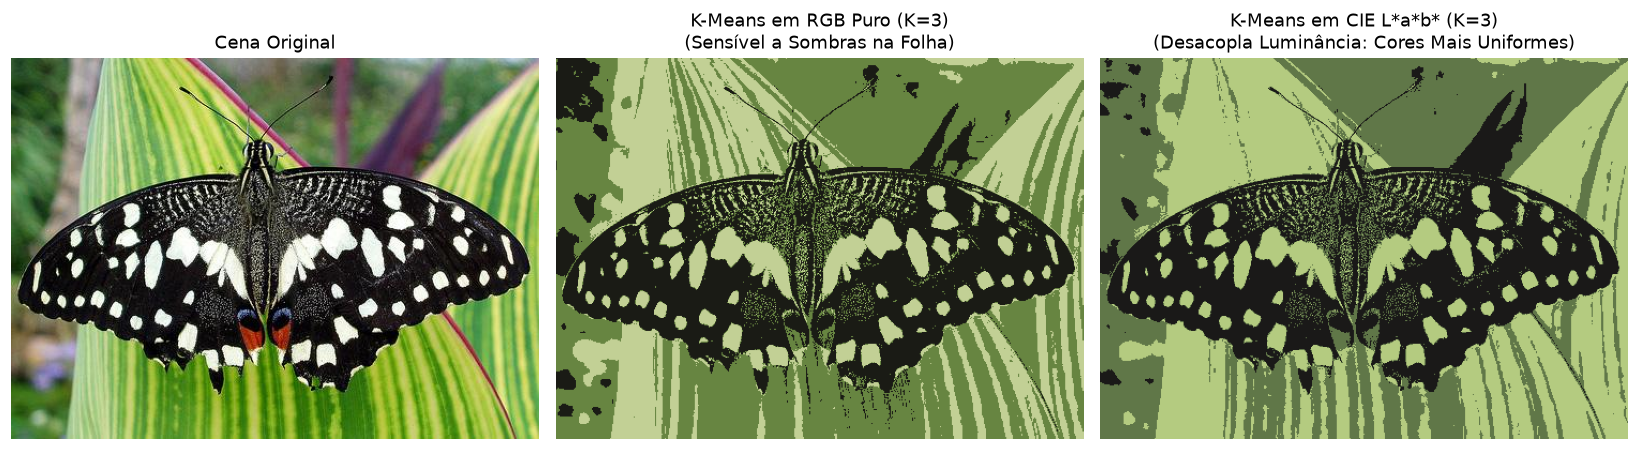

In [6]:
# Demonstração comparativa: K-Means no espaço RGB vs K-Means no espaço CIE L*a*b* (para K=3)
seg_rgb_espaco, _, _, _ = executar_kmeans(img_rgb, 3, usar_lab=False)
seg_lab_espaco, _, _, _ = executar_kmeans(img_rgb, 3, usar_lab=True)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb)
ax[0].set_title("Cena Original")
ax[0].axis("off")

ax[1].imshow(seg_rgb_espaco)
ax[1].set_title("K-Means em RGB Puro (K=3)\n(Sensível a Sombras na Folha)")
ax[1].axis("off")

ax[2].imshow(seg_lab_espaco)
ax[2].set_title("K-Means em CIE L*a*b* (K=3)\n(Desacopla Luminância: Cores Mais Uniformes)")
ax[2].axis("off")

plt.tight_layout()
plt.show()


## 💡 Síntese para a Apresentação Oral (Pontos de Fala do Slide 10)
Ao apresentar este slide perante a banca, destaque:
1. **O Espaço $L^*a^*b^*$:** Explicar que desacoplamos o brilho ($L^*$) das coordenadas de cromaticidade ($a^*, b^*$), fazendo com que variações de sombra na folhagem não quebrem a segmentação em regiões errôneas.
2. **O Efeito do Hiperparâmetro $K$:** $K=2$ funde planos importantes; $K=3$ atinge a partição semântica ideal entre objeto, vegetação e fundo; $K=5$ sobre-segmenta o fundo em múltiplos gradientes.
3. **A Falta de Conectividade Espacial:** Mostrar que pequenos reflexos na asa da borboleta caem no mesmo cluster de fundo porque têm cores semelhantes. Essa limitação é a motivação direta para o uso de Superpixels (SLIC em 5D).
